In [58]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch

In [59]:
# 1. Fetch dataset
adult = fetch_ucirepo(id=2)
X_df = adult.data.features  # DataFrame of shape (n_samples, n_features)
y_df = adult.data.targets   # DataFrame of shape (n_samples, 1)

# Convert X and y to numpy arrays
X = X_df.values
y = np.ravel(y_df.values)

# Map string labels to 0/1 (adjust exact strings if needed)
y = np.where(y == '>50K', 1, 0)

# Identify categorical and numerical columns by dtype
cat_cols = [i for i, dt in enumerate(X_df.dtypes) if dt.name in ['category', 'object', 'bool']]
num_cols = [i for i, dt in enumerate(X_df.dtypes) if np.issubdtype(dt, np.number)]

# 2. One-hot encode categoricals, standardize numericals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[:, cat_cols]) if cat_cols else np.empty((X.shape[0], 0))

scaler = StandardScaler()
X_num = scaler.fit_transform(X[:, num_cols]) if num_cols else np.empty((X.shape[0], 0))

# stack back together
X_all = np.hstack([X_num, X_cat])
y_all = y

# For balancing, create a single array with features and target as last column
df_all = np.hstack([X_all, y_all.reshape(-1, 1)])

In [60]:
# 1. Balance the dataset (upsample minority) using numpy
# Assume last column is target
target_col = -1
majority_mask = df_all[:, target_col] == 0
minority_mask = df_all[:, target_col] == 1

df_majority = df_all[majority_mask]
df_minority = df_all[minority_mask]

# Upsample minority class
n_majority = df_majority.shape[0]
n_minority = df_minority.shape[0]
np.random.seed(123)
indices = np.random.choice(n_minority, size=n_majority, replace=True)
df_minority_upsampled = df_minority[indices]

# Concatenate and shuffle
df_balanced = np.vstack([df_majority, df_minority_upsampled])
np.random.shuffle(df_balanced)

X_bal = df_balanced[:, :-1]
y_bal = df_balanced[:, -1]

# 2. PCA reduction to 4 components
scaler = StandardScaler()
X_bal_scaled = scaler.fit_transform(X_bal)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bal_scaled)

In [61]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_bal, test_size=0.2, random_state=123)

# 3. Train FFNNAgent on balanced data
ffnn_config = {
    'input_size': X_train.shape[1],
    'hidden_sizes': [32, 16],
    'output_size': 1,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 10,
    'type': 'classification',
    'classes': [0, 1],
    'seed': 123
}
agent = FFNNAgent(**ffnn_config)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=ffnn_config['batch_size'], shuffle=True)

agent.train(train_loader)
y_pred = agent.predict(X_test)
# If agent.predict returns a list or numpy array, .round() may not be available on lists.
# Convert to numpy array before rounding if needed.
if isinstance(y_pred, list):
    y_pred = np.array(y_pred)
f1_balanced = f1_score(y_test, np.round(y_pred))

FFNN Using device: cpu


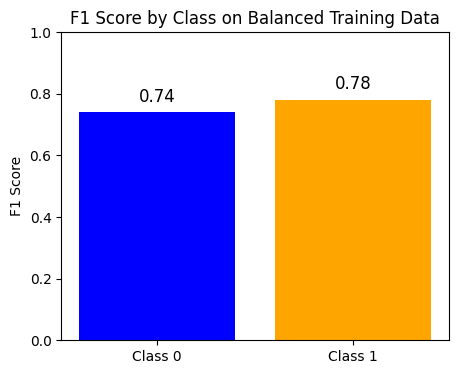

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Get predictions on the training set
y_train_pred = agent.predict(X_train)
if isinstance(y_train_pred, torch.Tensor):
    y_train_pred = y_train_pred.detach().cpu().numpy()
y_train_pred = np.array(y_train_pred).round().astype(int)
y_train_true = np.array(y_train).astype(int)

# Compute F1 score for each class (binary)
f1_class_0 = f1_score(y_train_true, y_train_pred, pos_label=0)
f1_class_1 = f1_score(y_train_true, y_train_pred, pos_label=1)

# Bar plot: F1 score for class 0 vs class 1
plt.figure(figsize=(5, 4))
plt.bar(['Class 0', 'Class 1'], [f1_class_0, f1_class_1], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('F1 Score by Class on Balanced Training Data')
for i, v in enumerate([f1_class_0, f1_class_1]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()


FFNN Using device: cpu


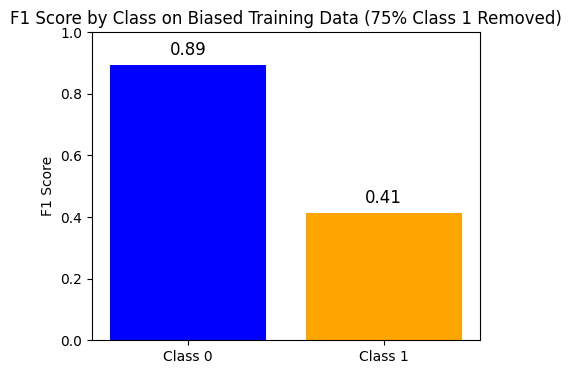

In [63]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# 1. Set bias percentage (adjustable)
remove_pct = 0.75  # 20% by default, change as needed

# 2. Bias the dataset: remove a percentage of Class 1 examples from the balanced training set
df_balanced = pd.DataFrame(X_train, columns=[f'feat_{i}' for i in range(X_train.shape[1])])
df_balanced['target'] = y_train

# Separate class 0 and class 1
df_class_0 = df_balanced[df_balanced['target'] == 0]
df_class_1 = df_balanced[df_balanced['target'] == 1]

# Remove a fraction of class 1
df_class_1_biased = df_class_1.sample(frac=1 - remove_pct, random_state=123)
df_biased = pd.concat([df_class_0, df_class_1_biased], axis=0).sample(frac=1, random_state=123).reset_index(drop=True)

X_biased = df_biased.drop('target', axis=1).values
y_biased = df_biased['target'].values

# 3. PCA analysis (just like before)
pca = PCA(n_components=2)
X_biased_pca = pca.fit_transform(X_biased)
# 4. Train and predict just like before
biased_dataset = TensorDataset(torch.tensor(X_biased, dtype=torch.float32), torch.tensor(y_biased, dtype=torch.long))
biased_loader = DataLoader(biased_dataset, batch_size=ffnn_config['batch_size'], shuffle=True)

# Re-initialize agent to avoid contamination from previous training
agent_biased = FFNNAgent(**ffnn_config)
agent_biased.train(biased_loader)
y_pred_biased = agent_biased.predict(X_test)
if isinstance(y_pred_biased, list):
    y_pred_biased = np.array(y_pred_biased)
f1_biased = f1_score(y_test, np.round(y_pred_biased))

# 5. Plot F1 score by class for biased data
y_train_pred_biased = agent_biased.predict(X_biased)
if isinstance(y_train_pred_biased, torch.Tensor):
    y_train_pred_biased = y_train_pred_biased.detach().cpu().numpy()
y_train_pred_biased = np.array(y_train_pred_biased).round().astype(int)
y_train_true_biased = np.array(y_biased).astype(int)

f1_class_0_biased = f1_score(y_train_true_biased, y_train_pred_biased, pos_label=0)
f1_class_1_biased = f1_score(y_train_true_biased, y_train_pred_biased, pos_label=1)

plt.figure(figsize=(5, 4))
plt.bar(['Class 0', 'Class 1'], [f1_class_0_biased, f1_class_1_biased], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title(f'F1 Score by Class on Biased Training Data ({int(remove_pct*100)}% Class 1 Removed)')
for i, v in enumerate([f1_class_0_biased, f1_class_1_biased]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)
plt.show()


In [64]:
def split_dataset(self, seq_len=5, seed=42):
    # 1. Fetch dataset
    adult = fetch_ucirepo(id=2)
    X_df = adult.data.features  # DataFrame of shape (n_samples, n_features)
    y_df = adult.data.targets   # DataFrame of shape (n_samples, 1)

    # Convert X and y to numpy arrays
    X = X_df.values
    y = np.ravel(y_df.values)

    # Map string labels to 0/1 (adjust exact strings if needed)
    y = np.where(y == '>50K', 1, 0)

    # Identify categorical and numerical columns by dtype
    cat_cols = [i for i, dt in enumerate(X_df.dtypes) if dt.name in ['category', 'object', 'bool']]
    num_cols = [i for i, dt in enumerate(X_df.dtypes) if np.issubdtype(dt, np.number)]

    # 2. One-hot encode categoricals, standardize numericals
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat = encoder.fit_transform(X[:, cat_cols]) if cat_cols else np.empty((X.shape[0], 0))

    scaler = StandardScaler()
    X_num = scaler.fit_transform(X[:, num_cols]) if num_cols else np.empty((X.shape[0], 0))

    # stack back together
    X_all = np.hstack([X_num, X_cat])
    y_all = y

    # For balancing, create a single array with features and target as last column
    df_all = np.hstack([X_all, y_all.reshape(-1, 1)])

    target_col = -1
    majority_mask = df_all[:, target_col] == 0
    minority_mask = df_all[:, target_col] == 1

    df_majority = df_all[majority_mask]
    df_minority = df_all[minority_mask]

    # Upsample minority class
    n_majority = df_majority.shape[0]
    n_minority = df_minority.shape[0]
    np.random.seed(123)
    indices = np.random.choice(n_minority, size=n_majority, replace=True)
    df_minority_upsampled = df_minority[indices]

    # Concatenate and shuffle
    df_balanced = np.vstack([df_majority, df_minority_upsampled])
    np.random.shuffle(df_balanced)

    X_bal = df_balanced[:, :-1]
    y_bal = df_balanced[:, -1]

    # 1. Set bias percentage (adjustable)
    remove_pct = 0.75  # 75% by default, change as needed

    # 2. Bias the dataset: remove a percentage of Class 1 examples from the balanced set
    df_balanced_pd = pd.DataFrame(X_bal, columns=[f'feat_{i}' for i in range(X_bal.shape[1])])
    df_balanced_pd['target'] = y_bal

    # Separate class 0 and class 1
    df_class_0 = df_balanced_pd[df_balanced_pd['target'] == 0]
    df_class_1 = df_balanced_pd[df_balanced_pd['target'] == 1]

    # Remove a fraction of class 1
    df_class_1_biased = df_class_1.sample(frac=1 - remove_pct, random_state=123)
    df_biased = pd.concat([df_class_0, df_class_1_biased], axis=0).sample(frac=1, random_state=123).reset_index(drop=True)

    X_biased = df_biased.drop('target', axis=1).values
    y_biased = df_biased['target'].values

    # 3. PCA analysis (just like before)
    pca = PCA(n_components=2)
    X_biased_pca = pca.fit_transform(X_biased)

    # 4. Train-test split after biasing and PCA
    X_train, X_test, y_train, y_test = train_test_split(
        X_biased_pca, y_biased, test_size=0.2, random_state=seed, stratify=y_biased
    )

    return X_train, X_test, y_train, y_test